# Introduction to Deep Learning, Assignment 2, Task 1

<div style="text-align: right">   </div>

In this notebook we are going to cover two generative models for generating novel images:

1. Variational Autoencoders (**VAEs**)
2. Generative adversarial networks (**GANs**)


<img src="https://lilianweng.github.io/lil-log/assets/images/three-generative-models.png" width="500">


Your main goal will be to retrain these models on a dataset of your choice and do some experiments on the learned latent space.

When using the Lab Computers, download the Jupyter Notebook to one of the machines first.

If you want to use Google Colab, you should first copy this notebook and enable GPU runtime in 'Runtime -> Change runtime type -> Hardware acceleration -> GPU **OR** TPU'.

In [ ]:
### If you are running on LIACS Lab machines, run the command below to reproduce the same package environment as Colab

#%pip install tf_keras==2.17.0 # Uncomment this to set up the right version

In [9]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

from tqdm import tqdm
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

#from google.colab import drive
# drive.mount('/content/drive', force_remount=True) ## If you want to use your google drive

2025-11-22 14:58:39.544641: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-22 14:58:39.549387: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-22 14:58:39.551309: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-22 14:58:39.556007: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-22 14:58:39.563287: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been 

New dataset


🌀 GENERATORE FRATTALI CON QUALITY CONTROL
🧪 Test qualità con 50 immagini...


Test qualità:   0%|          | 0/50 [00:00<?, ?it/s]

✅ Test completato!
📊 Qualità media immagini: 0.424
📈 Migliore: 0.892, Peggiore: 0.040


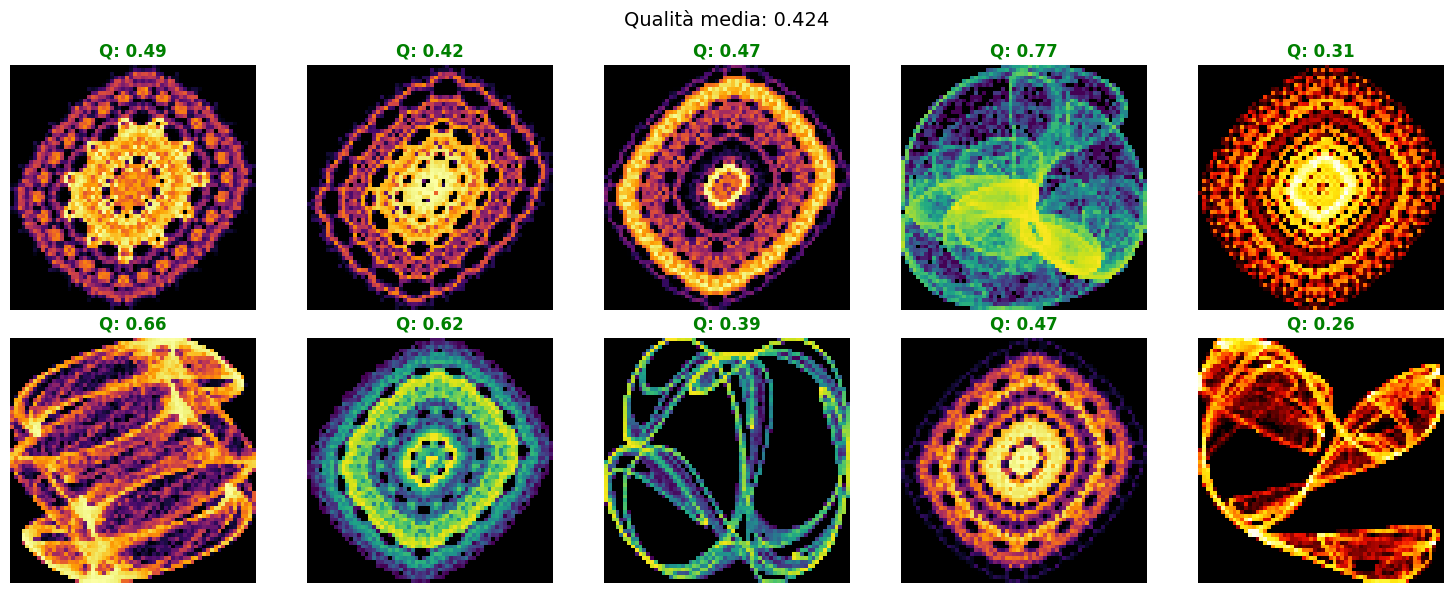


🎯 Le immagini ora hanno più dettagli! Procedere con 20,000?
💡 PER INTERROMPERE: Kernel → Interrupt

🚀 AVVIO GENERAZIONE DATASET QUALITY...
🎨 Creazione dataset QUALITY con 20000 immagini...
🔍 Filtro immagini troppo vuote...


Batch completati:   0%|          | 0/20 [00:00<?, ?it/s]

Batch 1/20:   0%|          | 0/1000 [00:00<?, ?it/s]

⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi 

Batch 2/20:   0%|          | 0/1000 [00:00<?, ?it/s]

...

⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi 

Batch 19/20:   0%|          | 0/1000 [00:00<?, ?it/s]

⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi 

Batch 20/20:   0%|          | 0/1000 [00:00<?, ?it/s]

⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi falliti
⚠️  Fallback dopo tentativi 

In [4]:
import numpy as np
import pandas as pd
import datashader as ds
from datashader import transfer_functions as tf
from datashader.colors import inferno, viridis
from math import sin, cos, sqrt, fabs
from colorcet import fire
from PIL import Image
import random
import os
from tqdm.notebook import tqdm

# Configurazione
n = 100000
IMG_SIZE = 64
DATASET_SIZE = 20000

def trajectory(fn, x0, y0, a, b=0, c=0, d=0, e=0, f=0, n=n):
    """Calcola le traiettorie degli attrattori"""
    x, y = np.zeros(n), np.zeros(n)
    x[0], y[0] = x0, y0
    for i in np.arange(n-1):
        x[i+1], y[i+1] = fn(x[i], y[i], a, b, c, d, e, f)
    return pd.DataFrame(dict(x=x,y=y))

# Funzioni attrattori
def Fractal_Dream(x, y, a, b, c, d, *o):
    return sin(y*b) + c*sin(x*b), sin(x*a) + d*sin(y*a)

def Hopalong1(x, y, a, b, c, *o):
    return y - sqrt(fabs(b * x - c)) * np.sign(x), a - x

def De_Jong(x, y, a, b, c, d, *o):
    return sin(a * y) - cos(b * x), sin(c * x) - cos(d * y)

def Clifford(x, y, a, b, c, d, *o):
    return sin(a * y) + c * cos(a * x), sin(b * x) + d * cos(b * y)

def is_image_valid(agg, min_density=0.15):
    """
    Controlla se l'immagine ha abbastanza dettagli
    min_density: percentuale minima di pixel non vuoti (0.15 = 15%)
    """
    # Conta i pixel non zero
    non_zero_pixels = np.count_nonzero(agg.values)
    total_pixels = agg.values.size
    
    density = non_zero_pixels / total_pixels
    return density >= min_density

def generate_quality_fractal_image(width=IMG_SIZE, height=IMG_SIZE, max_attempts=10):
    """
    Genera immagini frattali scartando quelle troppo vuote
    """
    attempts = 0
    
    while attempts < max_attempts:
        functions = [Fractal_Dream, Hopalong1, De_Jong, Clifford]
        fn = random.choice(functions)
        
        # Parametri ottimizzati per immagini più dense
        if fn == Fractal_Dream:
            vals = [random.uniform(-1, 1), random.uniform(-1, 1)] + [random.uniform(-2, 2) for _ in range(4)]
        elif fn == Hopalong1:
            vals = [random.uniform(-1, 1), random.uniform(-1, 1)] + [random.uniform(-2, 2) for _ in range(3)]
        else:
            vals = [random.uniform(-1, 1), random.uniform(-1, 1)] + [random.uniform(-2, 2) for _ in range(4)]
        
        try:
            df = trajectory(fn, *vals, n=n)
            cvs = ds.Canvas(plot_width=width, plot_height=height)
            agg = cvs.points(df, 'x', 'y')
            
            # Controlla se l'immagine è abbastanza densa
            if is_image_valid(agg, min_density=0.15):
                colormaps = [inferno, viridis, fire]
                cmap = random.choice(colormaps)
                
                img = tf.shade(agg, cmap=cmap, alpha=255)
                pil_img = tf.Image.to_pil(img)
                
                if pil_img.mode == 'RGBA':
                    rgb_img = Image.new("RGB", pil_img.size, (0, 0, 0))
                    rgb_img.paste(pil_img, mask=pil_img.split()[3])
                else:
                    rgb_img = pil_img.convert("RGB")
                
                return rgb_img, True
            else:
                attempts += 1
                continue
                
        except Exception as e:
            attempts += 1
            continue
    
    # Se dopo max_attempts non trova immagini buone, genera comunque una fallback
    print("⚠️  Fallback dopo tentativi falliti")
    return generate_fractal_image_fallback(width, height), False

def generate_fractal_image_fallback(width=IMG_SIZE, height=IMG_SIZE):
    """Genera un'immagine fallback con parametri garantiti"""
    # Parametri noti per produrre immagini dense
    good_params = [
        [0.1, 0.1, 1.8, -1.2, 0.5, -0.8],  # Fractal Dream denso
        [0.5, -0.5, -1.7, 1.3],            # Clifford denso
        [0.3, 0.3, 2.0, -2.0, 1.5, -1.5],  # De Jong denso
    ]
    
    fn = Fractal_Dream
    vals = random.choice(good_params)
    
    df = trajectory(fn, *vals, n=n)
    cvs = ds.Canvas(plot_width=width, plot_height=height)
    agg = cvs.points(df, 'x', 'y')
    
    colormaps = [inferno, viridis, fire]
    cmap = random.choice(colormaps)
    
    img = tf.shade(agg, cmap=cmap, alpha=255)
    pil_img = tf.Image.to_pil(img)
    
    if pil_img.mode == 'RGBA':
        rgb_img = Image.new("RGB", pil_img.size, (0, 0, 0))
        rgb_img.paste(pil_img, mask=pil_img.split()[3])
    else:
        rgb_img = pil_img.convert("RGB")
    
    return rgb_img

# 🎯 VERSIONE MIGLIORATA CON QUALITY CONTROL
def create_quality_fractal_dataset(num_images=DATASET_SIZE, batch_size=1000):
    """
    Crea dataset con controllo qualità delle immagini
    """
    images_array = []
    rejected_count = 0
    quality_scores = []
    
    print(f"🎨 Creazione dataset QUALITY con {num_images} immagini...")
    print("🔍 Filtro immagini troppo vuote...")
    
    batches = num_images // batch_size
    remaining = num_images % batch_size
    
    try:
        for batch in tqdm(range(batches), desc="Batch completati"):
            batch_images = []
            batch_rejected = 0
            
            for i in tqdm(range(batch_size), desc=f"Batch {batch+1}/{batches}", leave=False):
                img, is_quality = generate_quality_fractal_image()
                img_array = np.array(img) / 255.0
                
                if is_quality:
                    batch_images.append(img_array)
                    # Calcola "qualità" (densità dell'immagine)
                    density = np.mean(img_array > 0.1)  # Percentuale pixel sopra soglia
                    quality_scores.append(density)
                else:
                    batch_rejected += 1
                    rejected_count += 1
            
            images_array.extend(batch_images)
            
            # Salva progresso
            temp_dataset = np.array(images_array)
            np.save(f"quality_fractal_batch_{batch+1}.npy", temp_dataset)
            print(f"💾 Batch {batch+1}: {len(batch_images)} immagini, {batch_rejected} scartate")
        
        # Ultimo batch
        if remaining > 0:
            last_batch = []
            for i in tqdm(range(remaining), desc="Ultimo batch", leave=False):
                img, is_quality = generate_quality_fractal_image()
                img_array = np.array(img) / 255.0
                
                if is_quality:
                    last_batch.append(img_array)
                    density = np.mean(img_array > 0.1)
                    quality_scores.append(density)
                else:
                    rejected_count += 1
            
            images_array.extend(last_batch)
        
        # Dataset finale
        dataset = np.array(images_array)
        np.save("quality_fractal_dataset_64x64_rgb.npy", dataset)
        
        # Pulizia
        for i in range(1, batches + 1):
            temp_file = f"quality_fractal_batch_{i}.npy"
            if os.path.exists(temp_file):
                os.remove(temp_file)
        
        # Statistiche
        avg_quality = np.mean(quality_scores) if quality_scores else 0
        print(f"🎉 Dataset QUALITY completato!")
        print(f"📊 Immagini generate: {len(images_array)}")
        print(f"🚫 Immagini scartate: {rejected_count}")
        print(f"⭐ Qualità media: {avg_quality:.3f}")
        print(f"📈 Range qualità: [{np.min(quality_scores):.3f}, {np.max(quality_scores):.3f}]")
        
        return dataset
        
    except Exception as e:
        print(f"⏹️  Generazione interrotta: {e}")
        if images_array:
            dataset = np.array(images_array)
            np.save("quality_fractal_partial.npy", dataset)
            print(f"💾 Dataset parziale salvato: {dataset.shape}")
        return None

# 🚀 TEST CON QUALITY CONTROL
print("🌀 GENERATORE FRATTALI CON QUALITY CONTROL")
print("=" * 50)

# Test con controllo qualità
print("🧪 Test qualità con 50 immagini...")
test_images = []
quality_test = []

for i in tqdm(range(50), desc="Test qualità"):
    img, is_quality = generate_quality_fractal_image()
    img_array = np.array(img) / 255.0
    test_images.append(img_array)
    
    # Calcola densità per test
    density = np.mean(img_array > 0.1)
    quality_test.append(density)

test_dataset = np.array(test_images)
avg_quality = np.mean(quality_test)

print(f"✅ Test completato!")
print(f"📊 Qualità media immagini: {avg_quality:.3f}")
print(f"📈 Migliore: {np.max(quality_test):.3f}, Peggiore: {np.min(quality_test):.3f}")

# Mostra immagini di test con indicatore qualità
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(10):
    ax = axes[i//5, i%5]
    ax.imshow(test_images[i])
    ax.axis('off')
    quality = quality_test[i]
    color = 'green' if quality > 0.2 else 'orange' if quality > 0.15 else 'red'
    ax.set_title(f'Q: {quality:.2f}', color=color, fontweight='bold')
plt.suptitle(f'Qualità media: {avg_quality:.3f}', fontsize=14)
plt.tight_layout()
plt.show()

# 🎯 CONFERMA PER DATASET COMPLETO
print("\n" + "=" * 50)
print("🎯 Le immagini ora hanno più dettagli! Procedere con 20,000?")
print("💡 PER INTERROMPERE: Kernel → Interrupt")

response = 'SI'

if response.upper() == 'SI':
    print("\n🚀 AVVIO GENERAZIONE DATASET QUALITY...")
    dataset = create_quality_fractal_dataset(DATASET_SIZE, batch_size=1000)
    
    if dataset is not None:
        print("=" * 50)
        print("🎉 SUCCESSO! Dataset QUALITY pronto!")
        print(f"📊 Shape finale: {dataset.shape}")
        print(f"💾 File: quality_fractal_dataset_64x64_rgb.npy")
        
else:
    print("⏹️  Operazione annullata")

In [5]:
import numpy as np
import os
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

def concatenate_quality_fractals():
    """
    Concatena specificamente i tuoi 20 file quality_fractal_batch
    """
    print("🚀 CONCATENAZIONE DEI 20 BATCH QUALITY FRACTAL")
    print("=" * 60)
    
    # Lista dei tuoi file
    batch_files = [f"quality_fractal_batch_{i}.npy" for i in range(1, 21)]
    
    print(f"📁 TROVATI {len(batch_files)} FILE:")
    total_expected_images = 0
    batch_info = []
    
    # Verifica che tutti i file esistano e conta le immagini
    for batch_file in batch_files:
        if os.path.exists(batch_file):
            batch_data = np.load(batch_file)
            batch_images = len(batch_data)
            total_expected_images += batch_images
            batch_info.append((batch_file, batch_data.shape, batch_images))
            print(f"   ✅ {batch_file}: {batch_data.shape} ({batch_images} immagini)")
        else:
            print(f"   ❌ {batch_file}: NON TROVATO!")
            return None
    
    print(f"\n📊 TOTALE IMMAGINI ATTESE: {total_expected_images}")
    
    # Carica e concatena tutti i batch
    print(f"\n📦 CARICAMENTO E CONCATENAZIONE...")
    all_datasets = []
    
    for batch_file, shape, img_count in tqdm(batch_info, desc="Caricamento batch"):
        batch_data = np.load(batch_file)
        all_datasets.append(batch_data)
    
    # Concatena tutto
    print("🔄 Concatenazione in corso...")
    final_dataset = np.concatenate(all_datasets, axis=0)
    
    print(f"✅ Concatenazione completata!")
    print(f"   Shape finale: {final_dataset.shape}")
    
    # Salva il dataset finale
    output_filename = "final_quality_fractal_dataset_64x64_rgb.npy"
    print(f"\n💾 SALVATAGGIO DATASET FINALE...")
    np.save(output_filename, final_dataset)
    
    # Verifica
    file_size = os.path.getsize(output_filename) / (1024**3)  # GB
    print(f"   ✅ Salvato: {output_filename}")
    print(f"   💾 Dimensione: {file_size:.2f} GB")
    
    return final_dataset

def verify_concatenation():
    """
    Verifica che la concatenazione sia avvenuta correttamente
    """
    print("\n🔍 VERIFICA CONCATENAZIONE...")
    print("=" * 50)
    
    # Conta immagini totali dai batch originali
    total_original = 0
    for i in range(1, 21):
        batch_file = f"quality_fractal_batch_{i}.npy"
        if os.path.exists(batch_file):
            batch_data = np.load(batch_file)
            total_original += len(batch_data)
    
    # Carica dataset finale
    final_file = "final_quality_fractal_dataset_64x64_rgb.npy"
    if os.path.exists(final_file):
        final_data = np.load(final_file)
        final_images = len(final_data)
        
        print(f"📊 STATISTICHE:")
        print(f"   Immagini totali dai batch: {total_original}")
        print(f"   Immagini nel dataset finale: {final_images}")
        print(f"   Shape finale: {final_data.shape}")
        print(f"   Range valori: [{final_data.min():.3f}, {final_data.max():.3f}]")
        
        if total_original == final_images:
            print("   ✅ VERIFICA SUPERATA - Tutte le immagini presenti!")
        else:
            print(f"   ⚠️  DISCREPANZA: {total_original - final_images} immagini")
        
        return final_data
    else:
        print("❌ Dataset finale non trovato!")
        return None

def show_final_preview(dataset, num_samples=15):
    """
    Mostra un'anteprima del dataset finale
    """
    print(f"\n👁️  ANTEPRIMA DATASET FINALE")
    print(f"   Mostro {num_samples} immagini casuali su {len(dataset)} totali")
    
    # Seleziona immagini casuali
    indices = np.random.choice(len(dataset), min(num_samples, len(dataset)), replace=False)
    
    # Crea griglia 3x5
    cols = 5
    rows = (num_samples + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
    
    if rows == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        axes[i].imshow(dataset[idx])
        axes[i].set_title(f'Img {idx}', fontsize=8)
        axes[i].axis('off')
    
    # Nascondi assi vuoti
    for i in range(len(indices), len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# 🎯 ESECUZIONE PRINCIPALE
def main():
    """
    Concatenazione completa dei 20 batch
    """
    print("🌀 CONCATENAZIONE 20 BATCH QUALITY FRACTAL")
    print("=" * 60)
    
    # Step 1: Concatenazione
    print("1. 🔗 CONCATENAZIONE BATCH...")
    final_dataset = concatenate_quality_fractals()
    
    if final_dataset is None:
        print("❌ Concatenazione fallita!")
        return
    
    # Step 2: Verifica
    print("\n2. ✅ VERIFICA...")
    verified_dataset = verify_concatenation()
    
    # Step 3: Anteprima
    print("\n3. 👁️  ANTEPRIMA...")
    show_final_preview(verified_dataset if verified_dataset is not None else final_dataset)
    
    
    # Step 5: Informazioni finali
    print("\n" + "=" * 60)
    print("🎉 DATASET FINALE PRONTO!")
    print("=" * 60)
    print(f"📁 File: final_quality_fractal_dataset_64x64_rgb.npy")
    print(f"📊 Shape: {final_dataset.shape}")
    print(f"💾 Dimensione: {os.path.getsize('final_quality_fractal_dataset_64x64_rgb.npy') / (1024**3):.2f} GB")
    
    print(f"\n🔮 ORA PUOI USARLO CON LE RETI GENERATIVE:")

          
    

# 🚀 AVVIA LA CONCATENAZIONE
print("⚠️  PRONTO PER CONCATENARE I 20 BATCH!")
print("💡 Questo creerà un unico file con tutte le immagini")
print("📊 Dovresti ottenere circa 20,000 immagini 64x64 RGB")

main()

⚠️  PRONTO PER CONCATENARE I 20 BATCH!
💡 Questo creerà un unico file con tutte le immagini
📊 Dovresti ottenere circa 20,000 immagini 64x64 RGB
🌀 CONCATENAZIONE 20 BATCH QUALITY FRACTAL
1. 🔗 CONCATENAZIONE BATCH...
🚀 CONCATENAZIONE DEI 20 BATCH QUALITY FRACTAL
📁 TROVATI 20 FILE:
   ❌ quality_fractal_batch_1.npy: NON TROVATO!
❌ Concatenazione fallita!


In [ ]:
#!wget https://surfdrive.surf.nl/s/wxStiBetTKDJC32/download -O face_dataset_64x64.npy


### Dataset

This dataset is called [Flickr-Faces-HQ Dataset](https://github.com/NVlabs/ffhq-dataset). Here we will use a downsampled version of it (64x64x3) that will speed up all the experiments. [Download](https://surfdrive.surf.nl/s/wxStiBetTKDJC32).

After downloading you should copy it to your google drive's main directory (or modify the code to load it from elsewhere).

After running the notebook on this default dataset you then need to find a dataset of your own.

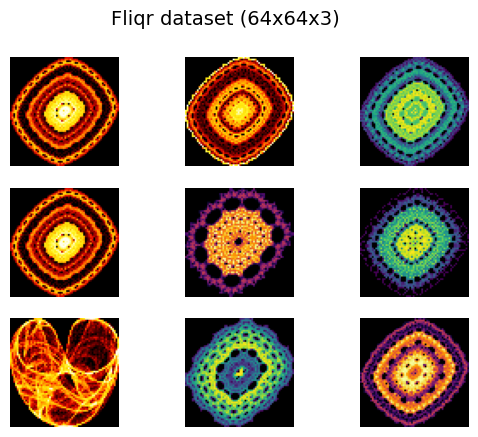

In [8]:
def load_real_samples(scale=False):
    # We load 20,000 samples only to avoid memory issues, you can  change this value
    X = np.load("quality_fractal_dataset_64x64_rgb.npy")
    # Scale samples in range [-127, 127]
    if scale:
        X = (X - 0.5) * 2
    return X 

# We will use this function to display the output of our models throughout this notebook
def grid_plot(images, epoch='', name='', n=3, save=False, scale=False):
    if scale:
        images = (images + 1) / 2.0
    for index in range(n * n):
        plt.subplot(n, n, 1 + index)
        plt.axis('off')
        plt.imshow(images[index])
    fig = plt.gcf()
    fig.suptitle(name + '  '+ str(epoch), fontsize=14)
    if save:
        filename = 'results/generated_plot_e%03d_f.png' % (epoch+1)
        plt.savefig(filename)
        plt.close()
    plt.show()


dataset = load_real_samples()
grid_plot(dataset[np.random.randint(0, 1000, 9)], name='Fliqr dataset (64x64x3)', n=3)

## 2.1. Introduction

The generative models that we are going to cover both have the following components:

1. A downsampling architecture (encoder in case of VAE, and discriminator in case of GAN) to either extract features from the data or model its distribution.
2. An upsampling architecture (decoder for VAE, generator for GAN) that will use some kind of latent vector to generate new samples that resemble the data that it was trained on.

Since we are going to be dealing with images, we are going to use convolutional networks for upsampling and downsampling, similar to what you see below.

<img src="https://i2.wp.com/sefiks.com/wp-content/uploads/2018/03/convolutional-autoencoder.png" width="500">


#### Code for building these components:

In [11]:
from tensorflow.keras.layers import Dense, Flatten, Conv2D, Conv2DTranspose, Reshape

def build_conv_net(in_shape, out_shape, n_downsampling_layers=4, filters=128, out_activation='sigmoid'):
    """
    Build a basic convolutional network
    """
    default_args=dict(kernel_size=(3,3), strides=(2,2), padding='same', activation='relu')

    input = tf.keras.Input(shape=in_shape)
    x = Conv2D(filters=filters, name='enc_input', **default_args)(input)

    for _ in range(n_downsampling_layers):
        x = Conv2D(**default_args, filters=filters)(x)

    x = Flatten()(x)
    x = Dense(out_shape, activation=out_activation, name='enc_output')(x)

    model = tf.keras.Model(inputs=input, outputs=x, name='Encoder')

    model.summary()
    return model


def build_deconv_net(latent_dim, n_upsampling_layers=4, filters=128, activation_out='sigmoid'):
    """
    Build a deconvolutional network for decoding/upscaling latent vectors

    When building the deconvolutional architecture, usually it is best to use the same layer sizes that
    were used in the downsampling network and the Conv2DTranspose layers are used instead of Conv2D layers.
    Using identical layers and hyperparameters ensures that the dimensionality of our output matches the
    shape of our input images.
    """
    input = tf.keras.Input(shape=(latent_dim,))
    x = Dense(4 * 4 * 64, input_dim=latent_dim, name='dec_input')(input)
    x = Reshape((4, 4, 64))(x) # This matches the output size of the downsampling architecture

    default_args=dict(kernel_size=(3,3), strides=(2,2), padding='same', activation='relu')

    for i in range(n_upsampling_layers):
        x = Conv2DTranspose(filters=filters, **default_args)(x)

    # This last convolutional layer converts back to 3 channel RGB image
    x = Conv2D(filters=3, kernel_size=(3,3), padding='same', activation=activation_out, name='dec_output')(x)

    model = tf.keras.Model(inputs=input, outputs=x, name='Decoder')
    model.summary()
    return model

### Convolutional Autoencoder example

Using these two basic building blocks we can now build a Convolutional Autoencoder (CAE).

<img src="https://lilianweng.github.io/lil-log/assets/images/autoencoder-architecture.png" width="500">



Even though it's not a generative model, CAE is a great way to illustrate how these two components (convolutional and deconvolutional networks) can be used together to reconstruct images.

You can view such model as a compression/dimensionality reduction method as each image gets compressed to a vector of 256 numbers by the encoder and gets decompressed back into an image using the decoder network.

Model: "Encoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 64, 64, 3)]       0         
                                                                 
 enc_input (Conv2D)          (None, 32, 32, 128)       3584      
                                                                 
 conv2d (Conv2D)             (None, 16, 16, 128)       147584    
                                                                 
 conv2d_1 (Conv2D)           (None, 8, 8, 128)         147584    
                                                                 
 conv2d_2 (Conv2D)           (None, 4, 4, 128)         147584    
                                                                 
 conv2d_3 (Conv2D)           (None, 2, 2, 128)         147584    
                                                                 
 flatten (Flatten)           (None, 512)               0   

I0000 00:00:1763819961.387392 2881724 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-11-22 14:59:21.434989: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2343] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...



Epoch:  0
1/1 [==============================] - 0s 121ms/step


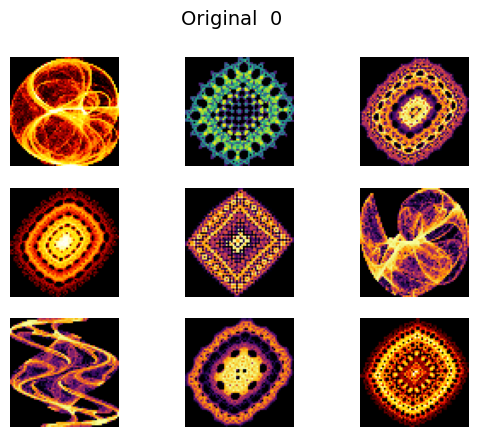

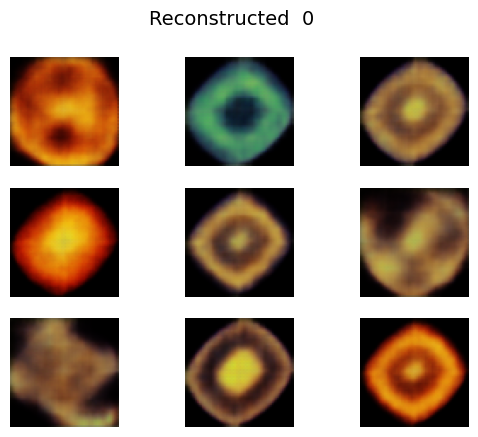


Epoch:  1
267/300 [=========================>....] - ETA: 6s - loss: 0.3433

In [ ]:
def build_convolutional_autoencoder(data_shape, latent_dim, filters=128):
    encoder = build_conv_net(in_shape=data_shape, out_shape=latent_dim, filters=filters)
    decoder = build_deconv_net(latent_dim, activation_out='sigmoid', filters=filters)

    # We connect encoder and decoder into a single model
    autoencoder = tf.keras.Sequential([encoder, decoder])

    # Binary crossentropy loss - pairwise comparison between input and output pixels
    autoencoder.compile(loss='binary_crossentropy', optimizer='adam')

    return autoencoder


# Defining the model dimensions and building it
image_size = dataset.shape[1:]
latent_dim = 512
num_filters = 128
cae = build_convolutional_autoencoder(image_size, latent_dim, num_filters)


## Training the Convolutional autoencoder to reconstruct images
for epoch in range(50):
    print('\nEpoch: ', epoch)

    # Note that (X=y) when training autoencoders!
    # In this case we only care about qualitative performance, we don't split into train/test sets
    cae.fit(x=dataset, y=dataset, epochs=1, batch_size=64)

    samples = dataset[:9]
    reconstructed = cae.predict(samples)
    grid_plot(samples, epoch, name='Original', n=3, save=False)
    grid_plot(reconstructed, epoch, name='Reconstructed', n=3, save=False)

*Note: You may experiment with the latent dimensionality and number of filters in your convolutional network to see how it affects the reconstruction quality. Remember that this also affects the size of the model and time it takes to train.*

---
---


## 2. 2. Variational Autoencoders (VAEs)

<img src="https://lilianweng.github.io/lil-log/assets/images/vae-gaussian.png" width="500">

#### Encoder network
This defines the approximate posterior distribution, which takes as input an observation and outputs a set of parameters for specifying the conditional distribution of the latent representation. In this example, we simply model the distribution as a diagonal Gaussian, and the network outputs the mean and log-variance parameters of a factorized Gaussian. We output log-variance instead of the variance directly for numerical stability.

#### Decoder network
This defines the conditional distribution of the observation $z$, which takes a latent sample $z$ as input and outputs the parameters for a conditional distribution of the observation. We model the latent distribution prior  as a unit Gaussian.

#### Reparameterization trick
To generate a sample  for the decoder during training, we can sample from the latent distribution defined by the parameters outputted by the encoder, given an input observation $z$. However, this sampling operation creates a bottleneck because backpropagation cannot flow through a random node.

To address this, we use a reparameterization trick. In our example, we approximate  using the decoder parameters and another parameter  as follows:

$$z = \mu + \sigma\epsilon$$

where $\mu$ and $\sigma$  represent the mean and standard deviation of a Gaussian distribution respectively. They can be derived from the decoder output. The  can be thought of as a random noise used to maintain stochasticity of $z$. We generate  from a standard normal distribution.

The latent variable  is now generated by a function of $\mu$ and $\sigma$ which would enable the model to backpropagate gradients in the encoder through $\mu$ and $\sigma$ respectively, while maintaining stochasticity through $\epsilon$.

#### Implementation

You can see how this trick is implemented below by creating a custom layer by sublassing tf.keras.layers.Layer.
It is then connected to the output of the original encoder architecture and an additional [KL](https://en.wikipedia.org/wiki/Kullback–Leibler_divergence) loss term is introduced.


In [ ]:
class Sampling(tf.keras.layers.Layer):
    """
    Custom layer for the variational autoencoder
    It takes two vectors as input - one for means and other for variances of the latent variables described by a multimodal gaussian
    Its output is a latent vector randomly sampled from this distribution
    """
    def call(self, inputs):
        z_mean, z_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_var) * epsilon

def build_vae(data_shape, latent_dim, filters=128):

    # Building the encoder - starts with a simple downsampling convolutional network
    encoder = build_conv_net(data_shape, latent_dim*2, filters=filters)

    # Adding special sampling layer that uses the reparametrization trick
    z_mean = Dense(latent_dim)(encoder.output)
    z_var = Dense(latent_dim)(encoder.output)
    z = Sampling()([z_mean, z_var])

    # Connecting the two encoder parts
    encoder = tf.keras.Model(inputs=encoder.input, outputs=z)

    # Defining the decoder which is a regular upsampling deconvolutional network
    decoder = build_deconv_net(latent_dim, activation_out='sigmoid', filters=filters)
    vae = tf.keras.Model(inputs=encoder.input, outputs=decoder(z))

    # Define a custom layer for the KL loss calculation
    class KLLossLayer(tf.keras.layers.Layer):
        def call(self, inputs):
            z_mean, z_var = inputs
            kl_loss = -0.5 * tf.reduce_sum(z_var - tf.square(z_mean) - tf.exp(z_var) + 1)
            # Add the KL loss to the model's losses
            self.add_loss(kl_loss / tf.cast(tf.keras.backend.prod(data_shape), tf.float32))
            return inputs  # Pass through the inputs unchanged

    # Apply the custom layer to z_mean and z_var
    _, _ = KLLossLayer()([z_mean, z_var])

    vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='binary_crossentropy')

    return encoder, decoder, vae

In [ ]:
# Training the VAE model

latent_dim = 64
encoder, decoder, vae = build_vae(dataset.shape[1:], latent_dim, filters=64)

for epoch in range(20):
    vae.fit(x=dataset, y=dataset, epochs=1, batch_size=8)

    # Generate random vectors that we will use to sample from the learned latent space
    coefficient = 6                                 # You can tweak this coefficient to increase/decrease the std of the sampled vectors
    latent_vectors = np.random.randn(9, latent_dim) # Generate 9 random points in the latent space
    images = decoder(latent_vectors / coefficient)  # Feed the vectors scaled by the coefficient to the model
    grid_plot(images, epoch, name='VAE generated images (randomly sampled from the latent space)', n=3, save=False)

*Note: again, you might experiment with the latent dimensionality, batch size and the architecture of your convolutional nets to see how it affects the generative capabilities of this model.*

---

## 2.3 Generative Adversarial Networks (GANs)

### GAN architecture
Generative adversarial networks consist of two models: a generative model and a discriminative model.

<img src="https://media.springernature.com/original/springer-static/image/chp%3A10.1007%2F978-1-4842-3679-6_8/MediaObjects/463582_1_En_8_Fig1_HTML.jpg" width="500">

**The discriminator** model is a classifier that determines whether a given image looks like a real image from the dataset or like an artificially created image. This is basically a binary classifier that will take the form of a normal convolutional neural network (CNN).
As an input this network will get samples both from the dataset that it is trained on and on the samples generated by the **generator**.

The **generator** model takes random input values (noise) and transforms them into images through a deconvolutional neural network.

Over the course of many training iterations, the weights and biases in the discriminator and the generator are trained through backpropagation. The discriminator learns to tell "real" images of handwritten digits apart from "fake" images created by the generator. At the same time, the generator uses feedback from the discriminator to learn how to produce convincing images that the discriminator can't distinguish from real images.




In [ ]:
from tensorflow.keras.optimizers.legacy import Adam

def build_gan(data_shape, latent_dim, filters=128, lr=0.0002, beta_1=0.5):
    optimizer = Adam(learning_rate=lr, beta_1=beta_1)

    # Usually thew GAN generator has tanh activation function in the output layer
    generator = build_deconv_net(latent_dim, activation_out='tanh', filters=filters)

    # Build and compile the discriminator
    discriminator = build_conv_net(in_shape=data_shape, out_shape=1, filters=filters) # Single output for binary classification
    discriminator.compile(loss='binary_crossentropy', optimizer=optimizer)

    # End-to-end GAN model for training the generator
    discriminator.trainable = False
    true_fake_prediction = discriminator(generator.output)
    GAN = tf.keras.Model(inputs=generator.input, outputs=true_fake_prediction)
    GAN.compile(loss='binary_crossentropy', optimizer=optimizer)

    return discriminator, generator, GAN


### Definining custom functions for training your GANs

---




In [ ]:
def get_batch(generator, dataset, batch_size=64):
    """
    Fetches one batch of data and ensures no memory leaks by using TensorFlow operations.
    """
    half_batch = batch_size // 2

    # Generate fake images
    latent_vectors = tf.random.normal(shape=(half_batch, latent_dim))
    fake_data = generator(latent_vectors, training=False)

    # Select real images
    idx = np.random.randint(0, dataset.shape[0], half_batch)
    real_data = dataset[idx]

    # Combine
    X = tf.concat([real_data, fake_data], axis=0)
    y = tf.concat([tf.ones((half_batch, 1)), tf.zeros((half_batch, 1))], axis=0)

    return X, y


def train_gan(generator, discriminator, gan, dataset, latent_dim, n_epochs=20, batch_size=64):
    """
    Train the GAN with memory-efficient updates and clear session management.
    """
    batches_per_epoch = dataset.shape[0] // batch_size

    for epoch in range(n_epochs):
        for batch in tqdm(range(batches_per_epoch)):
            # Train Discriminator
            X, y = get_batch(generator, dataset, batch_size)
            discriminator_loss = discriminator.train_on_batch(X, y)

            # Train Generator
            latent_vectors = tf.random.normal(shape=(batch_size, latent_dim))
            y_gan = tf.ones((batch_size, 1))
            generator_loss = gan.train_on_batch(latent_vectors, y_gan)

        # Generate and visualize after each epoch
        noise = tf.random.normal(shape=(16, latent_dim))
        generated_images = generator(noise, training=False)
        grid_plot(generated_images.numpy(), epoch, name='Generated Images', n=3)

        # Clear backend session to free memory
        tf.keras.backend.clear_session()


In [ ]:
## Build and train the model (need around 10 epochs to start seeing some results)

latent_dim = 256
discriminator, generator, gan = build_gan(dataset.shape[1:], latent_dim, filters=128)
dataset_scaled = load_real_samples(scale=True)

train_gan(generator, discriminator, gan, dataset_scaled, latent_dim, n_epochs=20)

*Note: the samples generated by small GANs are more diverse, when compared to VAEs, however some samples might look strange and do not resemble the data the model was trained on.

In [ ]:
# Your code